# Tests de robustesse Black-Litterman avec vues LLM

Ce notebook teste trois pistes pour diagnostiquer pourquoi les portefeuilles BL avec vues LLM sous-performent le S&P25 :

1. **Augmenter `Omega`** pour réduire la confiance accordée aux vues LLM.
2. **Mélanger les poids BL avec les poids de marché** pour limiter l'active share.
3. **Utiliser les vues comme signal de rang relatif** plutôt que comme prévision absolue de rendement mensuel.

La logique temporelle est :

```text
vues et poids au mois M → rendement réalisé au mois M+1
```

Le benchmark S&P25 est reconstruit directement à partir de `data/filtered_sp25_data.csv` avec les poids de capitalisation du mois M appliqués aux rendements du mois M+1.

In [1]:
# ============================
# 0. Imports et configuration
# ============================
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.options.display.float_format = "{:,.6f}".format

# ----------------------------
# Paramètres à ajuster au besoin
# ----------------------------
DATASET_CSV = Path("../data/filtered_sp25_data.csv")
RESPONSES_DIR = Path("../responses")
OUT_DIR = Path("diagnostics_bl_tests")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["gpt", "gemma3", "qwen", "llama"]  # ajuste selon tes fichiers disponibles
START = "2016-06-01"
END = "2025-06-30"
TAU = 0.025
LOOKBACK_MONTHS = 60
MIN_RET_ROWS = 2

# Prior market-implied : pi = delta * Sigma @ w_mkt
MARKET_RISK_AVERSION = 1.0

# Optimisation finale : min w'Sw - lambda * w'mu
# Pour être cohérent avec pi = delta * Sigma @ w_mkt et cet objectif sans facteur 1/2,
# lambda ≈ 2 / delta permet de retrouver le marché lorsque mu = pi.
PORTFOLIO_RISK_AVERSION = 2.0 / MARKET_RISK_AVERSION

# Test 1 : confiance envers les vues
OMEGA_MULTIPLIERS = [1, 2, 5, 10, 25, 50, 100]

# Test 2 : mélange avec le marché : w_final = (1-alpha) * w_mkt + alpha * w_bl
BLEND_ALPHAS = [0.10, 0.25, 0.50, 0.75, 1.00]
OMEGA_FOR_BLEND = 1.0

# Test 3 : vues relatives / par rang
# On garde seulement les top/bottom quantiles des scores LLM et on transforme le rang en petit tilt autour de pi.
RANK_QUANTILES = [0.20, 0.30]
RANK_VIEW_STRENGTHS = [0.25, 0.50, 1.00]
OMEGA_FOR_RANK = 10.0

# Petit plancher sur Omega pour éviter les vues trop confiantes
OMEGA_FLOOR = 1e-4

c:\Users\alexi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================
# 1. Fonctions utilitaires
# ============================

def clean_ticker(x) -> str:
    if x is None:
        return ""
    s = str(x).strip().strip('"').strip("'").upper()
    if not s or s in {"NAN", "NONE"}:
        return ""
    s = s.replace("-", ".")
    s = "".join(s.split())
    return s


def parse_dates(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        ss = pd.to_numeric(s, errors="coerce").astype("Int64").astype(str).str.zfill(8)
        return pd.to_datetime(ss, format="%Y%m%d", errors="coerce")
    ss = s.astype(str).str.strip()
    looks = ss.str.match(r"^\d{8}$")
    out = pd.Series(pd.NaT, index=s.index)
    out.loc[looks] = pd.to_datetime(ss.loc[looks], format="%Y%m%d", errors="coerce")
    out.loc[~looks] = pd.to_datetime(ss.loc[~looks], errors="coerce")
    return out


def month_pairs(start: str, end: str):
    s = pd.to_datetime(start)
    e = pd.to_datetime(end)
    ms = pd.date_range(s, e, freq="MS")
    return [(d.strftime("%Y-%m-%d"), (d + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")) for d in ms]


def project_to_psd(mat: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    A = 0.5 * (mat + mat.T)
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, eps, None)
    return (vecs * vals) @ vecs.T


def robust_covariance_psd(returns_used: pd.DataFrame) -> np.ndarray:
    if returns_used.shape[0] < 2 or returns_used.shape[1] < 2:
        n = returns_used.shape[1]
        return np.eye(n) * 1e-6
    sigma = returns_used.cov(min_periods=2).to_numpy(dtype=float)
    sigma = np.nan_to_num(sigma, nan=0.0, posinf=0.0, neginf=0.0)
    sigma = project_to_psd(sigma, eps=1e-12)
    n = sigma.shape[0]
    tr = float(np.trace(sigma))
    ridge = (1e-6 * (tr / n)) if np.isfinite(tr) and tr > 0 else 1e-6
    return sigma + np.eye(n) * ridge


def clip_vector(x: np.ndarray, z: float = 10.0) -> np.ndarray:
    x = np.asarray(x, dtype=float).reshape(-1)
    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    if np.isfinite(mad) and mad > 1e-12:
        scale = 1.4826 * mad
    else:
        sd = float(np.std(x))
        scale = sd if np.isfinite(sd) and sd > 1e-12 else 1.0
    return np.clip(x, med - z * scale, med + z * scale)


def robust_view_stats(samples) -> tuple[float, float, int]:
    s = pd.to_numeric(pd.Series(samples), errors="coerce").dropna().to_numpy(dtype=float)
    s = s[np.isfinite(s)]
    n = int(s.size)
    if n == 0:
        return np.nan, np.nan, 0
    med = float(np.median(s))
    mad = float(np.median(np.abs(s - med)))
    if np.isfinite(mad) and mad > 1e-12:
        scale = 1.4826 * mad
    else:
        sd = float(np.std(s))
        scale = sd if np.isfinite(sd) and sd > 1e-12 else 1.0
    s2 = np.clip(s, med - 5 * scale, med + 5 * scale)
    q = float(np.mean(s2))
    v = float(np.var(s2, ddof=1)) if n > 1 else OMEGA_FLOOR
    v = max(v, OMEGA_FLOOR)
    return q, v, n


def mean_variance_optimize(mu: np.ndarray, sigma: np.ndarray, risk_aversion: float) -> np.ndarray:
    mu = np.asarray(mu, dtype=float).reshape(-1)
    sigma = np.asarray(sigma, dtype=float)
    n = len(mu)
    if n == 0:
        return np.array([])

    def obj(w):
        return float(w.T @ sigma @ w) - float(risk_aversion) * float(w @ mu)

    constraints = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bounds = tuple((0.0, 1.0) for _ in range(n))
    x0 = np.ones(n) / n
    res = minimize(obj, x0, method="SLSQP", bounds=bounds, constraints=constraints, options={"maxiter": 2000})
    if (not res.success) or (not np.isfinite(res.x).all()):
        return x0
    w = np.clip(res.x, 0.0, None)
    s = w.sum()
    return w / s if s > 0 else x0


def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return np.nan
    if np.std(x[m]) < 1e-12 or np.std(y[m]) < 1e-12:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])

In [3]:
# ============================
# 2. Chargement du dataset et matrices mensuelles
# ============================

def load_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    required = {"date", "tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Colonnes manquantes dans {path}: {missing}")
    df = df.copy()
    df["date_dt"] = parse_dates(df["date"])
    df["tic"] = df["tic"].map(clean_ticker)
    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df = df.dropna(subset=["date_dt", "tic"]).copy()
    df = df[df["tic"] != ""].copy()
    df["ym"] = df["date_dt"].dt.to_period("M")
    return df.sort_values(["date_dt", "tic"])


def build_monthly_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    # Dernière observation du mois par titre
    d = df.sort_values(["ym", "tic", "date_dt"]).drop_duplicates(["ym", "tic"], keep="last")
    d["month_end_date"] = d.groupby("ym")["date_dt"].transform("max")
    return d[["ym", "month_end_date", "tic", "stock_ret", "market_equity"]].copy()


def get_returns_window(monthly: pd.DataFrame, end_date: str, lookback_months: int, tickers=None) -> pd.DataFrame:
    end_p = pd.Period(pd.to_datetime(end_date), freq="M")
    start_p = end_p - (lookback_months - 1)
    d = monthly[(monthly["ym"] >= start_p) & (monthly["ym"] <= end_p)].copy()
    if tickers is not None:
        tick_set = set(map(clean_ticker, tickers))
        d = d[d["tic"].isin(tick_set)].copy()
    if d.empty:
        return pd.DataFrame()
    R = d.pivot(index="ym", columns="tic", values="stock_ret").sort_index()
    R.index = R.index.to_timestamp(how="end")
    return R.dropna(axis=1, how="all")


def get_market_caps(monthly: pd.DataFrame, end_date: str) -> pd.Series:
    p = pd.Period(pd.to_datetime(end_date), freq="M")
    d = monthly[monthly["ym"] == p].copy()
    if d.empty:
        return pd.Series(dtype=float)
    caps = d.set_index("tic")["market_equity"].astype(float)
    caps = caps.replace([np.inf, -np.inf], np.nan).dropna()
    caps = caps[caps > 0]
    return caps


def get_realized_returns(monthly: pd.DataFrame, target_month_start: pd.Timestamp) -> pd.Series:
    p = pd.Period(target_month_start, freq="M")
    d = monthly[monthly["ym"] == p].copy()
    if d.empty:
        return pd.Series(dtype=float)
    return d.set_index("tic")["stock_ret"].astype(float)


def get_month_end_date(monthly: pd.DataFrame, target_month_start: pd.Timestamp):
    p = pd.Period(target_month_start, freq="M")
    d = monthly[monthly["ym"] == p]
    if d.empty:
        return target_month_start + pd.offsets.MonthEnd(0)
    return pd.to_datetime(d["month_end_date"].max())


dataset = load_dataset(DATASET_CSV)
monthly = build_monthly_snapshot(dataset)
print("Dataset:", DATASET_CSV)
print("Mois disponibles:", monthly["ym"].min(), "->", monthly["ym"].max())
print("Nb titres distincts:", monthly["tic"].nunique())

Dataset: ..\data\filtered_sp25_data.csv
Mois disponibles: 2014-12 -> 2025-06
Nb titres distincts: 43


In [4]:
# ============================
# 3. Fonctions Black-Litterman et variantes de test
# ============================

def load_responses(model: str, start_date: str, end_date: str) -> dict:
    path = RESPONSES_DIR / f"{model}_{start_date}_{end_date}.json"
    if not path.exists():
        return {}
    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)
    out = {}
    for k, v in raw.items():
        kk = clean_ticker(k)
        if isinstance(v, dict):
            out[kk] = v
    return out


def compute_market_prior(returns_df: pd.DataFrame, caps: pd.Series):
    caps = caps.copy()
    common = [t for t in returns_df.columns if t in caps.index]
    common = [t for t in common if returns_df[t].notna().sum() >= MIN_RET_ROWS]
    if len(common) < 2:
        raise ValueError("Pas assez de titres communs avec rendements et market caps.")

    R = returns_df[common].copy()
    caps = caps.loc[common].astype(float)
    w_mkt = (caps / caps.sum()).to_numpy(dtype=float)
    sigma = robust_covariance_psd(R)
    pi = float(MARKET_RISK_AVERSION) * (sigma @ w_mkt)
    pi = clip_vector(pi)
    return common, pi, sigma, w_mkt


def build_absolute_views(responses: dict, tickers: list[str]):
    q_map, omega_map, n_map = {}, {}, {}
    for t in tickers:
        vals = responses.get(t, {}).get("expected_return", None)
        if vals is None:
            continue
        if not isinstance(vals, list):
            vals = [vals]
        q, v, n = robust_view_stats(vals)
        if np.isfinite(q) and np.isfinite(v) and n > 0:
            q_map[t] = q
            omega_map[t] = v
            n_map[t] = n
    return q_map, omega_map, n_map


def bl_weights_absolute_views(
    responses: dict,
    returns_df: pd.DataFrame,
    tickers: list[str],
    pi: np.ndarray,
    sigma: np.ndarray,
    omega_multiplier: float = 1.0,
):
    q_map, omega_map, n_map = build_absolute_views(responses, tickers)
    keep = [t for t in tickers if t in q_map and returns_df[t].notna().sum() >= MIN_RET_ROWS]
    if len(keep) < 2:
        return pd.Series(np.nan, index=tickers), {"n_views": len(keep), "mean_omega": np.nan}

    idx = [tickers.index(t) for t in keep]
    pi_k = pi[idx]
    sigma_k = robust_covariance_psd(returns_df[keep].copy())
    Q = np.array([q_map[t] for t in keep], dtype=float)
    Omega = np.diag([max(OMEGA_FLOOR, omega_map[t]) * float(omega_multiplier) for t in keep])
    P = np.eye(len(keep))

    inv_tau_sigma = np.linalg.pinv(TAU * sigma_k)
    inv_omega = np.linalg.pinv(Omega)
    M = np.linalg.pinv(inv_tau_sigma + P.T @ inv_omega @ P)
    posterior = M @ (inv_tau_sigma @ pi_k + P.T @ inv_omega @ Q)
    posterior = clip_vector(posterior)

    w_k = mean_variance_optimize(posterior, sigma_k, PORTFOLIO_RISK_AVERSION)
    w = pd.Series(0.0, index=tickers, dtype=float)
    w.loc[keep] = w_k
    s = w.sum()
    if s > 0:
        w /= s
    info = {
        "n_views": len(keep),
        "mean_omega": float(np.mean(np.diag(Omega))),
        "mean_abs_view_minus_pi": float(np.mean(np.abs(Q - pi_k))),
        "view_dispersion": float(np.std(Q)),
    }
    return w, info


def bl_weights_rank_views(
    responses: dict,
    returns_df: pd.DataFrame,
    tickers: list[str],
    pi: np.ndarray,
    sigma: np.ndarray,
    rank_quantile: float = 0.2,
    view_strength: float = 0.5,
    omega_multiplier: float = 10.0,
):
    q_map, omega_map, n_map = build_absolute_views(responses, tickers)
    scores = pd.Series({t: q_map[t] for t in tickers if t in q_map}, dtype=float).dropna()
    scores = scores[[t for t in scores.index if t in tickers and returns_df[t].notna().sum() >= MIN_RET_ROWS]]
    if len(scores) < 5:
        return pd.Series(np.nan, index=tickers), {"n_views": len(scores), "mean_omega": np.nan}

    lo = scores.quantile(rank_quantile)
    hi = scores.quantile(1.0 - rank_quantile)
    selected = scores[(scores <= lo) | (scores >= hi)].copy()
    keep = list(selected.index)
    if len(keep) < 2:
        return pd.Series(np.nan, index=tickers), {"n_views": len(keep), "mean_omega": np.nan}

    idx = [tickers.index(t) for t in keep]
    pi_k = pi[idx]
    sigma_k = robust_covariance_psd(returns_df[keep].copy())

    # Transformation en signal relatif : seulement le rang compte.
    ranks = selected.rank(pct=True).reindex(keep).to_numpy(dtype=float)
    z = (ranks - 0.5) / 0.5  # environ [-1, 1]

    # Échelle prudente : petite variation autour de pi, basée sur la dispersion du prior.
    pi_scale = float(np.nanstd(pi))
    if not np.isfinite(pi_scale) or pi_scale < 1e-6:
        pi_scale = 0.01
    Q = pi_k + float(view_strength) * pi_scale * z

    # Omega volontairement plus large que dans les vues absolues.
    base_omega = []
    for t in keep:
        v = omega_map.get(t, np.nan)
        if not np.isfinite(v):
            v = OMEGA_FLOOR
        base_omega.append(max(OMEGA_FLOOR, v) * float(omega_multiplier))
    Omega = np.diag(base_omega)
    P = np.eye(len(keep))

    inv_tau_sigma = np.linalg.pinv(TAU * sigma_k)
    inv_omega = np.linalg.pinv(Omega)
    M = np.linalg.pinv(inv_tau_sigma + P.T @ inv_omega @ P)
    posterior = M @ (inv_tau_sigma @ pi_k + P.T @ inv_omega @ Q)
    posterior = clip_vector(posterior)

    w_k = mean_variance_optimize(posterior, sigma_k, PORTFOLIO_RISK_AVERSION)
    w = pd.Series(0.0, index=tickers, dtype=float)
    w.loc[keep] = w_k
    s = w.sum()
    if s > 0:
        w /= s

    info = {
        "n_views": len(keep),
        "mean_omega": float(np.mean(np.diag(Omega))),
        "mean_abs_view_minus_pi": float(np.mean(np.abs(Q - pi_k))),
        "view_dispersion": float(np.std(Q)),
    }
    return w, info

In [ ]:
# ============================
# 4. Simulation des tests
# ============================

periods = month_pairs(START, END)
rows = []
weights_rows = []

for model in MODELS:
    print(f"\n=== Modèle: {model} ===")
    for start_date, end_date in tqdm(periods, desc=model):
        weight_month = pd.to_datetime(start_date).to_period("M").to_timestamp()
        target_month = (weight_month + pd.offsets.MonthBegin(1)).to_period("M").to_timestamp()
        target_returns = get_realized_returns(monthly, target_month)
        if target_returns.empty:
            continue

        responses = load_responses(model, start_date, end_date)
        if len(responses) < 2:
            continue

        returns_df = get_returns_window(monthly, end_date, LOOKBACK_MONTHS, tickers=None)
        if returns_df.shape[0] < MIN_RET_ROWS or returns_df.shape[1] < 2:
            continue

        caps = get_market_caps(monthly, end_date)
        if caps.empty:
            continue

        try:
            tickers, pi, sigma, w_mkt = compute_market_prior(returns_df, caps)
        except Exception:
            continue

        returns_df = returns_df[tickers].copy()
        r_next = target_returns.reindex(tickers).astype(float)
        finite_ret = np.isfinite(r_next.to_numpy(dtype=float))
        if finite_ret.sum() < 2:
            continue

        # Benchmark S&P25 cap-weighted, poids M -> rendements M+1
        w_mkt_s = pd.Series(w_mkt, index=tickers, dtype=float)
        w_mkt_f = w_mkt_s.iloc[np.where(finite_ret)[0]]
        r_f = r_next.iloc[np.where(finite_ret)[0]]
        w_mkt_f = w_mkt_f / w_mkt_f.sum()
        sp25_ret = float((w_mkt_f * r_f).sum())

        # Vue diagnostic : corrélation des scores LLM vs rendement suivant
        q_map, _, _ = build_absolute_views(responses, tickers)
        q_s = pd.Series(q_map, dtype=float).reindex(tickers)
        view_realized_corr = safe_corr(q_s.reindex(r_next.index), r_next)
        hit_rate = np.nan
        valid_hr = q_s.notna() & r_next.notna()
        if valid_hr.sum() > 0:
            hit_rate = float((np.sign(q_s[valid_hr]) == np.sign(r_next[valid_hr])).mean())

        # Test 1: Omega multipliers
        base_bl_for_blend = None
        for om in OMEGA_MULTIPLIERS:
            w_bl, info = bl_weights_absolute_views(responses, returns_df, tickers, pi, sigma, omega_multiplier=om)
            if w_bl.isna().all():
                continue
            if float(om) == float(OMEGA_FOR_BLEND):
                base_bl_for_blend = w_bl.copy()
            variant = f"omega_x{om:g}"
            port_ret = float((w_bl.reindex(r_f.index).fillna(0.0) * r_f).sum() / max(w_bl.reindex(r_f.index).fillna(0.0).sum(), 1e-12))
            active_share = 0.5 * float(np.abs(w_bl.reindex(tickers).fillna(0.0) - w_mkt_s).sum())
            top5_weight = float(w_bl.sort_values(ascending=False).head(5).sum())
            rows.append({
                "model": model, "test_family": "omega", "variant": variant,
                "omega_multiplier": om, "blend_alpha": np.nan, "rank_quantile": np.nan, "rank_view_strength": np.nan,
                "weight_month": weight_month, "target_month": target_month, "date_key": get_month_end_date(monthly, target_month),
                "portfolio_return": port_ret, "sp25_return": sp25_ret, "active_return": port_ret - sp25_ret,
                "view_realized_corr": view_realized_corr, "view_hit_rate": hit_rate,
                "active_share": active_share, "top5_weight": top5_weight, "n_nonzero": int((w_bl > 1e-8).sum()),
                **info,
            })

        # Test 2: blend avec marché
        if base_bl_for_blend is None:
            base_bl_for_blend, _ = bl_weights_absolute_views(responses, returns_df, tickers, pi, sigma, omega_multiplier=OMEGA_FOR_BLEND)
        if not base_bl_for_blend.isna().all():
            for alpha in BLEND_ALPHAS:
                w_blend = (1.0 - alpha) * w_mkt_s + alpha * base_bl_for_blend.reindex(tickers).fillna(0.0)
                w_blend = w_blend.clip(lower=0.0)
                w_blend = w_blend / w_blend.sum()
                variant = f"blend_alpha_{alpha:g}_omega_{OMEGA_FOR_BLEND:g}"
                port_ret = float((w_blend.reindex(r_f.index).fillna(0.0) * r_f).sum() / max(w_blend.reindex(r_f.index).fillna(0.0).sum(), 1e-12))
                active_share = 0.5 * float(np.abs(w_blend - w_mkt_s).sum())
                top5_weight = float(w_blend.sort_values(ascending=False).head(5).sum())
                rows.append({
                    "model": model, "test_family": "blend", "variant": variant,
                    "omega_multiplier": OMEGA_FOR_BLEND, "blend_alpha": alpha, "rank_quantile": np.nan, "rank_view_strength": np.nan,
                    "weight_month": weight_month, "target_month": target_month, "date_key": get_month_end_date(monthly, target_month),
                    "portfolio_return": port_ret, "sp25_return": sp25_ret, "active_return": port_ret - sp25_ret,
                    "view_realized_corr": view_realized_corr, "view_hit_rate": hit_rate,
                    "active_share": active_share, "top5_weight": top5_weight, "n_nonzero": int((w_blend > 1e-8).sum()),
                    "n_views": np.nan, "mean_omega": np.nan, "mean_abs_view_minus_pi": np.nan, "view_dispersion": np.nan,
                })

        # Test 3: vues par rang relatif
        for q in RANK_QUANTILES:
            for strength in RANK_VIEW_STRENGTHS:
                w_rank, info = bl_weights_rank_views(
                    responses, returns_df, tickers, pi, sigma,
                    rank_quantile=q,
                    view_strength=strength,
                    omega_multiplier=OMEGA_FOR_RANK,
                )
                if w_rank.isna().all():
                    continue
                variant = f"rank_q{q:g}_strength_{strength:g}_omega_{OMEGA_FOR_RANK:g}"
                port_ret = float((w_rank.reindex(r_f.index).fillna(0.0) * r_f).sum() / max(w_rank.reindex(r_f.index).fillna(0.0).sum(), 1e-12))
                active_share = 0.5 * float(np.abs(w_rank.reindex(tickers).fillna(0.0) - w_mkt_s).sum())
                top5_weight = float(w_rank.sort_values(ascending=False).head(5).sum())
                rows.append({
                    "model": model, "test_family": "rank", "variant": variant,
                    "omega_multiplier": OMEGA_FOR_RANK, "blend_alpha": np.nan, "rank_quantile": q, "rank_view_strength": strength,
                    "weight_month": weight_month, "target_month": target_month, "date_key": get_month_end_date(monthly, target_month),
                    "portfolio_return": port_ret, "sp25_return": sp25_ret, "active_return": port_ret - sp25_ret,
                    "view_realized_corr": view_realized_corr, "view_hit_rate": hit_rate,
                    "active_share": active_share, "top5_weight": top5_weight, "n_nonzero": int((w_rank > 1e-8).sum()),
                    **info,
                })

results = pd.DataFrame(rows)
print("Nombre de lignes:", len(results))
display(results.head())


=== Modèle: gpt ===


gpt: 100%|██████████| 109/109 [00:17<00:00,  6.22it/s]



=== Modèle: gemma3 ===


gemma3:  94%|█████████▍| 103/109 [00:16<00:01,  5.69it/s]

In [ ]:
# ============================
# 5. Métriques de performance et résumé
# ============================

def perf_metrics(g: pd.DataFrame) -> pd.Series:
    r = g["portfolio_return"].astype(float)
    rb = g["sp25_return"].astype(float)
    active = r - rb
    n = len(r)
    if n == 0:
        return pd.Series(dtype=float)
    cum = float((1 + r).prod() - 1)
    cum_b = float((1 + rb).prod() - 1)
    ann = float((1 + r).prod() ** (12 / n) - 1) if n > 0 else np.nan
    ann_b = float((1 + rb).prod() ** (12 / n) - 1) if n > 0 else np.nan
    vol = float(r.std(ddof=1) * np.sqrt(12)) if n > 1 else np.nan
    vol_b = float(rb.std(ddof=1) * np.sqrt(12)) if n > 1 else np.nan
    te = float(active.std(ddof=1) * np.sqrt(12)) if n > 1 else np.nan
    sharpe_like = ann / vol if vol and np.isfinite(vol) and vol > 0 else np.nan
    info_ratio = float(active.mean() * 12 / te) if te and np.isfinite(te) and te > 0 else np.nan
    max_dd = float(((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min())
    return pd.Series({
        "n_months": n,
        "cum_return": cum,
        "sp25_cum_return": cum_b,
        "ann_return": ann,
        "sp25_ann_return": ann_b,
        "ann_active_return": ann - ann_b,
        "ann_vol": vol,
        "sp25_ann_vol": vol_b,
        "tracking_error": te,
        "information_ratio": info_ratio,
        "sharpe_like": sharpe_like,
        "max_drawdown": max_dd,
        "mean_monthly_active": float(active.mean()),
        "hit_months_vs_sp25": float((active > 0).mean()),
        "mean_active_share": float(g["active_share"].mean()),
        "mean_top5_weight": float(g["top5_weight"].mean()),
        "mean_turnover_placeholder": np.nan,
        "mean_view_corr": float(g["view_realized_corr"].mean()),
        "mean_view_hit_rate": float(g["view_hit_rate"].mean()),
        "mean_n_nonzero": float(g["n_nonzero"].mean()),
        "mean_n_views": float(g["n_views"].mean()),
    })

summary = (
    results
    .sort_values(["model", "test_family", "variant", "date_key"])
    .groupby(["model", "test_family", "variant"], dropna=False)
    .apply(perf_metrics)
    .reset_index()
)

# Rang par modèle selon rendement annualisé actif
summary["rank_within_model"] = summary.groupby("model")["ann_active_return"].rank(ascending=False, method="first")
summary_sorted = summary.sort_values(["model", "rank_within_model"])

display(summary_sorted.head(40))

,model,test_family,variant,n_months,cum_return,sp25_cum_return,ann_return,sp25_ann_return,ann_active_return,ann_vol,sp25_ann_vol,tracking_error,information_ratio,sharpe_like,max_drawdown,mean_monthly_active,hit_months_vs_sp25,mean_active_share,mean_top5_weight,mean_turnover_placeholder,mean_view_corr,mean_view_hit_rate,mean_n_nonzero,mean_n_views,rank_within_model
8,gemma3,omega,omega_x2,108.000000,17.678204,3.823919,0.384393,0.191059,0.193334,0.298053,0.172284,0.201636,0.899738,1.289683,-0.349816,0.015118,0.601852,0.877276,1.000000,NaN,0.008195,0.559659,1.925926,21.805556,1.000000
10,gemma3,omega,omega_x5,108.000000,16.551182,3.823919,0.374853,0.191059,0.183794,0.300088,0.172284,0.203270,0.860341,1.249143,-0.384104,0.014573,0.546296,0.859917,1.000000,NaN,0.008195,0.559659,2.231481,21.805556,2.000000
4,gemma3,blend,blend_alpha_1_omega_1,108.000000,15.234315,3.823919,0.362990,0.191059,0.171931,0.298226,0.172284,0.205326,0.806461,1.217166,-0.324812,0.013799,0.601852,0.883295,1.000000,NaN,0.008195,0.559659,1.842593,NaN,3.000000
5,gemma3,omega,omega_x1,108.000000,15.234315,3.823919,0.362990,0.191059,0.171931,0.298226,0.172284,0.205326,0.806461,1.217166,-0.324812,0.013799,0.601852,0.883295,1.000000,NaN,0.008195,0.559659,1.842593,21.805556,4.000000
6,gemma3,omega,omega_x10,108.000000,14.217489,3.823919,0.353229,0.191059,0.162170,0.295358,0.172284,0.197552,0.796306,1.195936,-0.410722,0.013109,0.518519,0.836984,0.999788,NaN,0.008195,0.559659,2.601852,21.805556,5.000000
9,gemma3,omega,omega_x25,108.000000,11.707815,3.823919,0.326400,0.191059,0.135341,0.273122,0.172284,0.169060,0.773918,1.195070,-0.381107,0.010903,0.564815,0.757197,0.993367,NaN,0.008195,0.559659,4.037037,21.805556,6.000000
3,gemma3,blend,blend_alpha_0.75_omega_1,108.000000,11.418717,3.823919,0.323013,0.191059,0.131954,0.258003,0.172284,0.154757,0.805095,1.251972,-0.306109,0.010383,0.601852,0.662471,0.866392,NaN,0.008195,0.559659,22.861111,NaN,7.000000
11,gemma3,omega,omega_x50,108.000000,9.209996,3.823919,0.294535,0.191059,0.103476,0.239613,0.172284,0.123592,0.793728,1.229216,-0.357621,0.008175,0.555556,0.656752,0.954462,NaN,0.008195,0.559659,6.342593,21.805556,8.000000
2,gemma3,blend,blend_alpha_0.5_omega_1,108.000000,8.283906,3.823919,0.280931,0.191059,0.089872,0.221660,0.172284,0.103697,0.803522,1.267393,-0.288465,0.006944,0.601852,0.441647,0.732985,NaN,0.008195,0.559659,22.861111,NaN,9.000000
7,gemma3,omega,omega_x100,108.000000,6.269425,3.823919,0.246586,0.191059,0.055527,0.211163,0.172284,0.086510,0.618418,1.167754,-0.317380,0.004458,0.574074,0.518741,0.833329,NaN,0.008195,0.559659,10.925926,21.805556,10.000000


In [ ]:
# ============================
# 6. Tableaux ciblés par test
# ============================

omega_summary = summary[summary["test_family"] == "omega"].copy()
blend_summary = summary[summary["test_family"] == "blend"].copy()
rank_summary = summary[summary["test_family"] == "rank"].copy()

print("Meilleures variantes Omega par modèle")
display(
    omega_summary.sort_values(["model", "ann_active_return"], ascending=[True, False])
    .groupby("model")
    .head(10)
)

print("Meilleures variantes Blend par modèle")
display(
    blend_summary.sort_values(["model", "ann_active_return"], ascending=[True, False])
    .groupby("model")
    .head(10)
)

print("Meilleures variantes Rank-relative par modèle")
display(
    rank_summary.sort_values(["model", "ann_active_return"], ascending=[True, False])
    .groupby("model")
    .head(10)
)

Meilleures variantes Omega par modèle


,model,test_family,variant,n_months,cum_return,sp25_cum_return,ann_return,sp25_ann_return,ann_active_return,ann_vol,sp25_ann_vol,tracking_error,information_ratio,sharpe_like,max_drawdown,mean_monthly_active,hit_months_vs_sp25,mean_active_share,mean_top5_weight,mean_turnover_placeholder,mean_view_corr,mean_view_hit_rate,mean_n_nonzero,mean_n_views,rank_within_model
8,gemma3,omega,omega_x2,108.000000,17.678204,3.823919,0.384393,0.191059,0.193334,0.298053,0.172284,0.201636,0.899738,1.289683,-0.349816,0.015118,0.601852,0.877276,1.000000,NaN,0.008195,0.559659,1.925926,21.805556,1.000000
10,gemma3,omega,omega_x5,108.000000,16.551182,3.823919,0.374853,0.191059,0.183794,0.300088,0.172284,0.203270,0.860341,1.249143,-0.384104,0.014573,0.546296,0.859917,1.000000,NaN,0.008195,0.559659,2.231481,21.805556,2.000000
5,gemma3,omega,omega_x1,108.000000,15.234315,3.823919,0.362990,0.191059,0.171931,0.298226,0.172284,0.205326,0.806461,1.217166,-0.324812,0.013799,0.601852,0.883295,1.000000,NaN,0.008195,0.559659,1.842593,21.805556,4.000000
6,gemma3,omega,omega_x10,108.000000,14.217489,3.823919,0.353229,0.191059,0.162170,0.295358,0.172284,0.197552,0.796306,1.195936,-0.410722,0.013109,0.518519,0.836984,0.999788,NaN,0.008195,0.559659,2.601852,21.805556,5.000000
9,gemma3,omega,omega_x25,108.000000,11.707815,3.823919,0.326400,0.191059,0.135341,0.273122,0.172284,0.169060,0.773918,1.195070,-0.381107,0.010903,0.564815,0.757197,0.993367,NaN,0.008195,0.559659,4.037037,21.805556,6.000000
11,gemma3,omega,omega_x50,108.000000,9.209996,3.823919,0.294535,0.191059,0.103476,0.239613,0.172284,0.123592,0.793728,1.229216,-0.357621,0.008175,0.555556,0.656752,0.954462,NaN,0.008195,0.559659,6.342593,21.805556,8.000000
7,gemma3,omega,omega_x100,108.000000,6.269425,3.823919,0.246586,0.191059,0.055527,0.211163,0.172284,0.086510,0.618418,1.167754,-0.317380,0.004458,0.574074,0.518741,0.833329,NaN,0.008195,0.559659,10.925926,21.805556,10.000000
27,gpt,omega,omega_x25,108.000000,9.255036,3.823919,0.295169,0.191059,0.104110,0.278188,0.172284,0.166141,0.648677,1.061042,-0.427070,0.008981,0.546296,0.728173,0.984344,NaN,0.025052,0.545022,4.518519,21.805556,1.000000
29,gpt,omega,omega_x50,108.000000,8.090726,3.823919,0.277941,0.191059,0.086882,0.244666,0.172284,0.125414,0.685347,1.136003,-0.367601,0.007163,0.518519,0.626786,0.940355,NaN,0.025052,0.545022,6.842593,21.805556,2.000000
24,gpt,omega,omega_x10,108.000000,7.724481,3.823919,0.272116,0.191059,0.081057,0.300689,0.172284,0.192644,0.497706,0.904974,-0.464507,0.007990,0.500000,0.813942,0.998735,NaN,0.025052,0.545022,2.750000,21.805556,3.000000


Meilleures variantes Blend par modèle


,model,test_family,variant,n_months,cum_return,sp25_cum_return,ann_return,sp25_ann_return,ann_active_return,ann_vol,sp25_ann_vol,tracking_error,information_ratio,sharpe_like,max_drawdown,mean_monthly_active,hit_months_vs_sp25,mean_active_share,mean_top5_weight,mean_turnover_placeholder,mean_view_corr,mean_view_hit_rate,mean_n_nonzero,mean_n_views,rank_within_model
4,gemma3,blend,blend_alpha_1_omega_1,108.000000,15.234315,3.823919,0.362990,0.191059,0.171931,0.298226,0.172284,0.205326,0.806461,1.217166,-0.324812,0.013799,0.601852,0.883295,1.000000,NaN,0.008195,0.559659,1.842593,NaN,3.000000
3,gemma3,blend,blend_alpha_0.75_omega_1,108.000000,11.418717,3.823919,0.323013,0.191059,0.131954,0.258003,0.172284,0.154757,0.805095,1.251972,-0.306109,0.010383,0.601852,0.662471,0.866392,NaN,0.008195,0.559659,22.861111,NaN,7.000000
2,gemma3,blend,blend_alpha_0.5_omega_1,108.000000,8.283906,3.823919,0.280931,0.191059,0.089872,0.221660,0.172284,0.103697,0.803522,1.267393,-0.288465,0.006944,0.601852,0.441647,0.732985,NaN,0.008195,0.559659,22.861111,NaN,9.000000
1,gemma3,blend,blend_alpha_0.25_omega_1,108.000000,5.776282,3.823919,0.236894,0.191059,0.045835,0.191797,0.172284,0.052121,0.801701,1.235124,-0.272012,0.003482,0.601852,0.220824,0.601366,NaN,0.008195,0.559659,22.861111,NaN,11.000000
0,gemma3,blend,blend_alpha_0.1_omega_1,108.000000,4.543329,3.823919,0.209598,0.191059,0.018539,0.178561,0.172284,0.020916,0.800470,1.173822,-0.275628,0.001395,0.601852,0.088329,0.525758,NaN,0.008195,0.559659,22.861111,NaN,15.000000
22,gpt,blend,blend_alpha_1_omega_1,108.000000,6.963604,3.823919,0.259283,0.191059,0.068224,0.338650,0.172284,0.237098,0.409905,0.765636,-0.589228,0.008099,0.509259,0.867731,1.000000,NaN,0.025052,0.545022,1.629630,NaN,4.000000
21,gpt,blend,blend_alpha_0.75_omega_1,108.000000,6.311952,3.823919,0.247394,0.191059,0.056335,0.288778,0.172284,0.178750,0.406863,0.856692,-0.515174,0.006061,0.509259,0.650799,0.869297,NaN,0.025052,0.545022,22.861111,NaN,6.000000
20,gpt,blend,blend_alpha_0.5_omega_1,108.000000,5.539596,3.823919,0.232017,0.191059,0.040958,0.242202,0.172284,0.119822,0.403410,0.957947,-0.430050,0.004028,0.509259,0.433866,0.739193,NaN,0.025052,0.545022,22.861111,NaN,9.000000
19,gpt,blend,blend_alpha_0.25_omega_1,108.000000,4.694291,3.823919,0.213215,0.191059,0.022156,0.201705,0.172284,0.060261,0.399471,1.057064,-0.350609,0.002006,0.509259,0.216933,0.609678,NaN,0.025052,0.545022,22.861111,NaN,11.000000
18,gpt,blend,blend_alpha_0.1_omega_1,108.000000,4.172133,3.823919,0.200319,0.191059,0.009260,0.182293,0.172284,0.024194,0.396834,1.098887,-0.310454,0.000800,0.509259,0.086773,0.533013,NaN,0.025052,0.545022,22.861111,NaN,17.000000


Meilleures variantes Rank-relative par modèle


,model,test_family,variant,n_months,cum_return,sp25_cum_return,ann_return,sp25_ann_return,ann_active_return,ann_vol,sp25_ann_vol,tracking_error,information_ratio,sharpe_like,max_drawdown,mean_monthly_active,hit_months_vs_sp25,mean_active_share,mean_top5_weight,mean_turnover_placeholder,mean_view_corr,mean_view_hit_rate,mean_n_nonzero,mean_n_views,rank_within_model
17,gemma3,rank,rank_q0.3_strength_1_omega_10,108.000000,5.078242,3.823919,0.222043,0.191059,0.030984,0.190497,0.172284,0.053351,0.548539,1.165596,-0.276598,0.002439,0.555556,0.451160,0.633872,NaN,0.008195,0.559659,12.185185,13.648148,12.000000
16,gemma3,rank,rank_q0.3_strength_0.5_omega_10,108.000000,4.724165,3.823919,0.213920,0.191059,0.022861,0.188093,0.172284,0.051436,0.428775,1.137315,-0.288316,0.001838,0.527778,0.449463,0.624223,NaN,0.008195,0.559659,12.250000,13.648148,13.000000
15,gemma3,rank,rank_q0.3_strength_0.25_omega_10,108.000000,4.706348,3.823919,0.213500,0.191059,0.022441,0.187473,0.172284,0.050813,0.424998,1.138828,-0.292029,0.001800,0.537037,0.451598,0.622572,NaN,0.008195,0.559659,12.185185,13.648148,14.000000
14,gemma3,rank,rank_q0.2_strength_1_omega_10,108.000000,4.494639,3.823919,0.208413,0.191059,0.017354,0.193826,0.172284,0.074200,0.249376,1.075260,-0.347132,0.001542,0.527778,0.596002,0.749015,NaN,0.008195,0.559659,8.620370,9.583333,16.000000
13,gemma3,rank,rank_q0.2_strength_0.5_omega_10,108.000000,4.365434,3.823919,0.205222,0.191059,0.014163,0.193573,0.172284,0.073944,0.213237,1.060179,-0.351465,0.001314,0.527778,0.596524,0.747356,NaN,0.008195,0.559659,8.629630,9.583333,17.000000
12,gemma3,rank,rank_q0.2_strength_0.25_omega_10,108.000000,4.189428,3.823919,0.200764,0.191059,0.009705,0.191653,0.172284,0.072530,0.161005,1.047542,-0.357074,0.000973,0.527778,0.593920,0.742376,NaN,0.008195,0.559659,8.703704,9.583333,18.000000
32,gpt,rank,rank_q0.2_strength_1_omega_10,108.000000,4.446203,3.823919,0.207225,0.191059,0.016166,0.200423,0.172284,0.074689,0.249774,1.033940,-0.302195,0.001555,0.509259,0.580800,0.753379,NaN,0.025052,0.545022,8.611111,9.574074,12.000000
34,gpt,rank,rank_q0.3_strength_0.5_omega_10,108.000000,4.316101,3.823919,0.203986,0.191059,0.012927,0.188391,0.172284,0.051316,0.269223,1.082783,-0.303553,0.001151,0.490741,0.426857,0.624039,NaN,0.025052,0.545022,12.324074,13.648148,13.000000
35,gpt,rank,rank_q0.3_strength_1_omega_10,108.000000,4.264112,3.823919,0.202672,0.191059,0.011613,0.188585,0.172284,0.048157,0.264916,1.074700,-0.295015,0.001063,0.481481,0.425909,0.630982,NaN,0.025052,0.545022,12.259259,13.648148,14.000000
31,gpt,rank,rank_q0.2_strength_0.5_omega_10,108.000000,4.218510,3.823919,0.201510,0.191059,0.010451,0.199170,0.172284,0.074664,0.182330,1.011746,-0.307296,0.001134,0.537037,0.583300,0.752272,NaN,0.025052,0.545022,8.564815,9.574074,15.000000


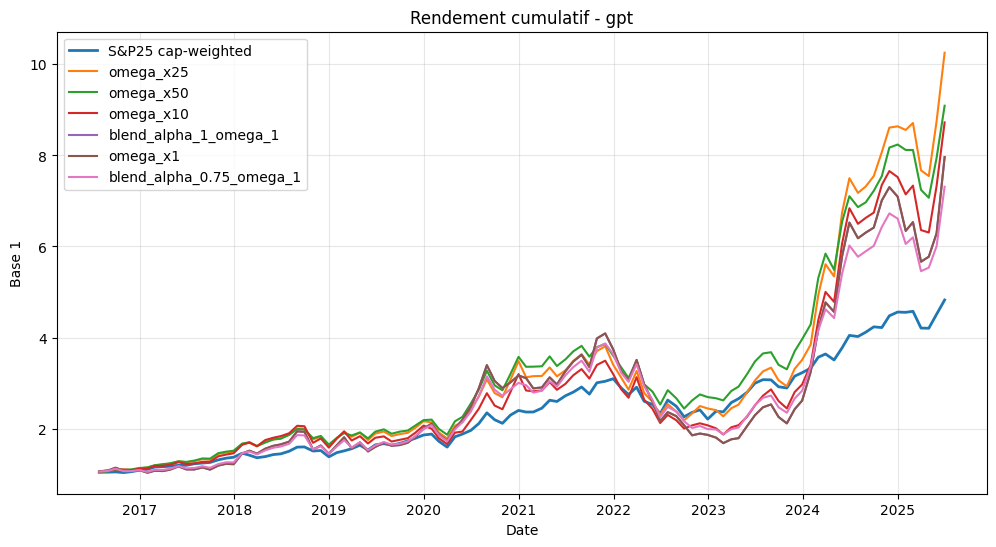

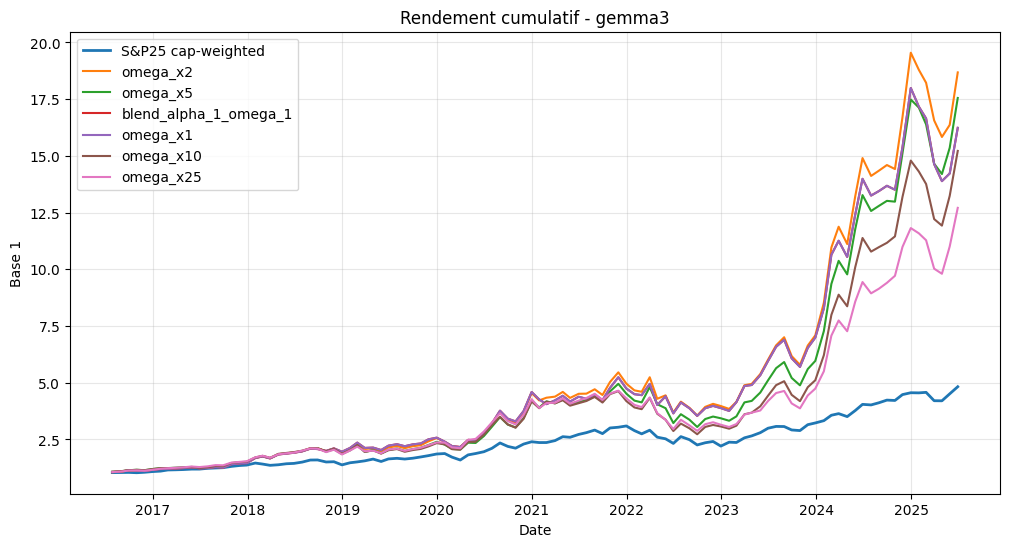

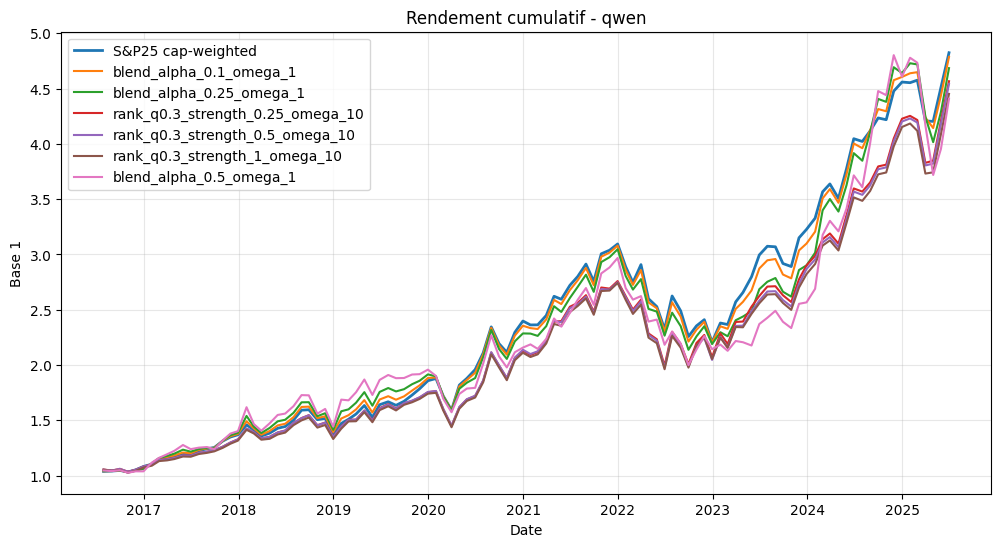

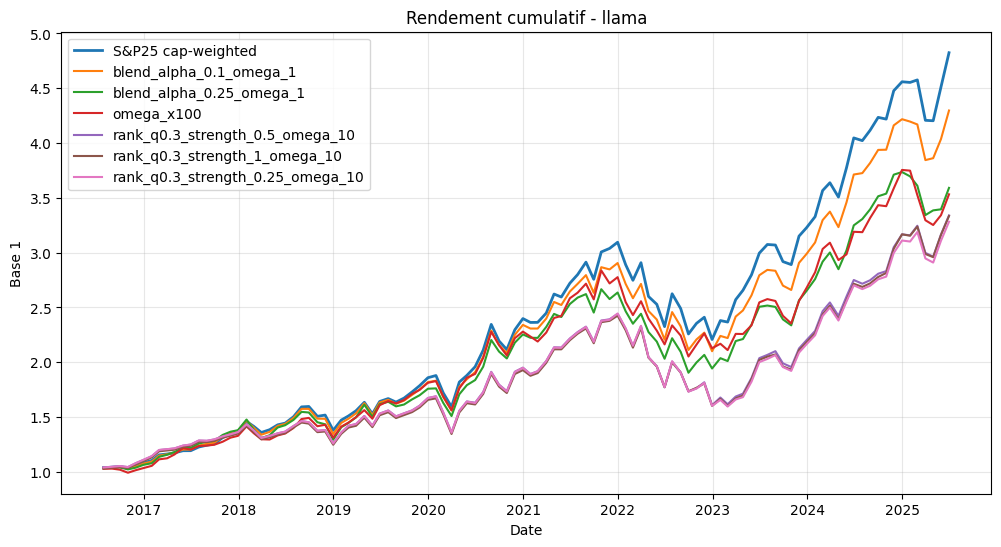

In [ ]:
# ============================
# 7. Graphiques de comparaison
# ============================

def plot_cumulative_for_model(model: str, variants: list[str] | None = None):
    d = results[results["model"] == model].copy()
    if d.empty:
        print(f"Aucune donnée pour {model}")
        return
    if variants is None:
        best = (
            summary[summary["model"] == model]
            .sort_values("ann_active_return", ascending=False)
            .head(6)["variant"].tolist()
        )
        variants = best
    plt.figure(figsize=(12, 6))
    # benchmark, une seule fois
    b = d.drop_duplicates("date_key").sort_values("date_key")
    plt.plot(b["date_key"], (1 + b["sp25_return"]).cumprod(), label="S&P25 cap-weighted", linewidth=2)
    for v in variants:
        dv = d[d["variant"] == v].sort_values("date_key")
        if dv.empty:
            continue
        plt.plot(dv["date_key"], (1 + dv["portfolio_return"]).cumprod(), label=v)
    plt.title(f"Rendement cumulatif - {model}")
    plt.xlabel("Date")
    plt.ylabel("Base 1")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for m in MODELS:
    plot_cumulative_for_model(m)

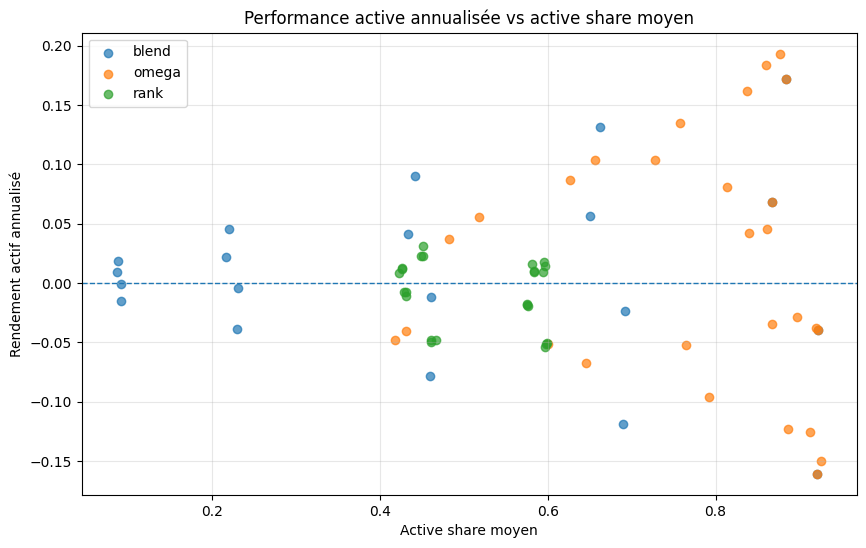

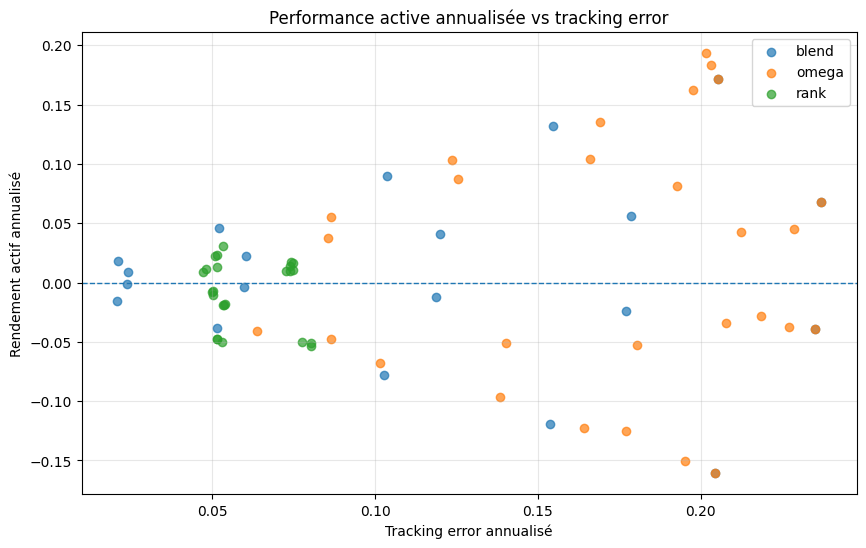

In [ ]:
# ============================
# 8. Graphiques synthèses : performance vs risque actif
# ============================

plt.figure(figsize=(10, 6))
for family in summary["test_family"].dropna().unique():
    d = summary[summary["test_family"] == family]
    plt.scatter(d["mean_active_share"], d["ann_active_return"], label=family, alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Performance active annualisée vs active share moyen")
plt.xlabel("Active share moyen")
plt.ylabel("Rendement actif annualisé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
for family in summary["test_family"].dropna().unique():
    d = summary[summary["test_family"] == family]
    plt.scatter(d["tracking_error"], d["ann_active_return"], label=family, alpha=0.7)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Performance active annualisée vs tracking error")
plt.xlabel("Tracking error annualisé")
plt.ylabel("Rendement actif annualisé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ============================
# 9. Analyse automatique : diagnostic textuel simple
# ============================

best_by_model = summary.sort_values("ann_active_return", ascending=False).groupby("model").head(1)
base_omega = summary[summary["variant"] == "omega_x1"].copy()

print("Meilleure variante par modèle:")
display(best_by_model[[
    "model", "test_family", "variant", "ann_return", "sp25_ann_return", "ann_active_return",
    "tracking_error", "information_ratio", "mean_active_share", "mean_top5_weight", "hit_months_vs_sp25"
]])

print("Baseline omega_x1:")
display(base_omega[[
    "model", "variant", "ann_return", "sp25_ann_return", "ann_active_return",
    "tracking_error", "mean_active_share", "mean_top5_weight", "hit_months_vs_sp25"
]])

for model in MODELS:
    b = base_omega[base_omega["model"] == model]
    best = best_by_model[best_by_model["model"] == model]
    if b.empty or best.empty:
        continue
    b_ar = float(b["ann_active_return"].iloc[0])
    best_ar = float(best["ann_active_return"].iloc[0])
    best_var = best["variant"].iloc[0]
    print(f"{model}: meilleure amélioration vs omega_x1 = {best_ar - b_ar:.2%} annualisé | meilleure variante = {best_var}")

Meilleure variante par modèle:


,model,test_family,variant,ann_return,sp25_ann_return,ann_active_return,tracking_error,information_ratio,mean_active_share,mean_top5_weight,hit_months_vs_sp25
8,gemma3,omega,omega_x2,0.384393,0.191059,0.193334,0.201636,0.899738,0.877276,1.000000,0.601852
27,gpt,omega,omega_x25,0.295169,0.191059,0.104110,0.166141,0.648677,0.728173,0.984344,0.546296
54,qwen,blend,blend_alpha_0.1_omega_1,0.190021,0.191059,-0.001039,0.023895,-0.010857,0.092240,0.525651,0.509259
36,llama,blend,blend_alpha_0.1_omega_1,0.175842,0.191059,-0.015218,0.020656,-0.665454,0.092034,0.508667,0.435185


Baseline omega_x1:


,model,variant,ann_return,sp25_ann_return,ann_active_return,tracking_error,mean_active_share,mean_top5_weight,hit_months_vs_sp25
5,gemma3,omega_x1,0.362990,0.191059,0.171931,0.205326,0.883295,1.000000,0.601852
23,gpt,omega_x1,0.259283,0.191059,0.068224,0.237098,0.867731,1.000000,0.509259
41,llama,omega_x1,0.030267,0.191059,-0.160792,0.204341,0.920342,1.000000,0.435185
59,qwen,omega_x1,0.151739,0.191059,-0.039320,0.235009,0.922403,1.000000,0.509259


gpt: meilleure amélioration vs omega_x1 = 3.59% annualisé | meilleure variante = omega_x25
gemma3: meilleure amélioration vs omega_x1 = 2.14% annualisé | meilleure variante = omega_x2
qwen: meilleure amélioration vs omega_x1 = 3.83% annualisé | meilleure variante = blend_alpha_0.1_omega_1
llama: meilleure amélioration vs omega_x1 = 14.56% annualisé | meilleure variante = blend_alpha_0.1_omega_1


In [ ]:
# ============================
# 10. Exports
# ============================

results_path = OUT_DIR / f"bl_tests_monthly_results_tau_{TAU}_{START}_{END}.csv"
summary_path = OUT_DIR / f"bl_tests_summary_tau_{TAU}_{START}_{END}.csv"
excel_path = OUT_DIR / f"bl_tests_report_tau_{TAU}_{START}_{END}.xlsx"

results.to_csv(results_path, index=False)
summary_sorted.to_csv(summary_path, index=False)

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    results.to_excel(writer, sheet_name="monthly_results", index=False)
    summary_sorted.to_excel(writer, sheet_name="summary_all", index=False)
    omega_summary.sort_values(["model", "ann_active_return"], ascending=[True, False]).to_excel(writer, sheet_name="omega", index=False)
    blend_summary.sort_values(["model", "ann_active_return"], ascending=[True, False]).to_excel(writer, sheet_name="blend", index=False)
    rank_summary.sort_values(["model", "ann_active_return"], ascending=[True, False]).to_excel(writer, sheet_name="rank", index=False)

print("Exports créés:")
print(results_path)
print(summary_path)
print(excel_path)

Exports créés:
diagnostics_bl_tests\bl_tests_monthly_results_tau_0.025_2016-06-01_2025-06-30.csv
diagnostics_bl_tests\bl_tests_summary_tau_0.025_2016-06-01_2025-06-30.csv
diagnostics_bl_tests\bl_tests_report_tau_0.025_2016-06-01_2025-06-30.xlsx


Résumé des variantes ciblées


,model,test_family,variant,n_months,ann_return,sp25_ann_return,ann_active_return,ann_vol,tracking_error,information_ratio,max_drawdown,hit_months_vs_sp25,mean_active_share,mean_top5_weight,mean_n_nonzero,mean_view_corr,mean_view_hit_rate,target_rank_within_model
0,gemma3,omega,omega_x25,108.000000,0.326400,0.191059,0.135341,0.273122,0.169060,0.773918,-0.381107,0.564815,0.757197,0.993367,4.037037,0.008195,0.559659,1.000000
1,gemma3,omega,omega_x50,108.000000,0.294535,0.191059,0.103476,0.239613,0.123592,0.793728,-0.357621,0.555556,0.656752,0.954462,6.342593,0.008195,0.559659,2.000000
2,gemma3,blend,blend_alpha_0.5_omega_1,108.000000,0.280931,0.191059,0.089872,0.221660,0.103697,0.803522,-0.288465,0.601852,0.441647,0.732985,22.861111,0.008195,0.559659,3.000000
3,gemma3,blend,blend_alpha_0.25_omega_1,108.000000,0.236894,0.191059,0.045835,0.191797,0.052121,0.801701,-0.272012,0.601852,0.220824,0.601366,22.861111,0.008195,0.559659,4.000000
4,gemma3,rank,rank_q0.3_strength_1_omega_10,108.000000,0.222043,0.191059,0.030984,0.190497,0.053351,0.548539,-0.276598,0.555556,0.451160,0.633872,12.185185,0.008195,0.559659,5.000000
5,gpt,omega,omega_x25,108.000000,0.295169,0.191059,0.104110,0.278188,0.166141,0.648677,-0.427070,0.546296,0.728173,0.984344,4.518519,0.025052,0.545022,1.000000
6,gpt,omega,omega_x50,108.000000,0.277941,0.191059,0.086882,0.244666,0.125414,0.685347,-0.367601,0.518519,0.626786,0.940355,6.842593,0.025052,0.545022,2.000000
7,gpt,blend,blend_alpha_0.5_omega_1,108.000000,0.232017,0.191059,0.040958,0.242202,0.119822,0.403410,-0.430050,0.509259,0.433866,0.739193,22.861111,0.025052,0.545022,3.000000
8,gpt,blend,blend_alpha_0.25_omega_1,108.000000,0.213215,0.191059,0.022156,0.201705,0.060261,0.399471,-0.350609,0.509259,0.216933,0.609678,22.861111,0.025052,0.545022,4.000000
9,gpt,rank,rank_q0.2_strength_1_omega_10,108.000000,0.207225,0.191059,0.016166,0.200423,0.074689,0.249774,-0.302195,0.509259,0.580800,0.753379,8.611111,0.025052,0.545022,5.000000



Toutes les variantes ciblées sont disponibles.


,model,test_family,variant,omega_multiplier,blend_alpha,rank_quantile,rank_view_strength,weight_month,target_month,date_key,portfolio_return,sp25_return,active_return,view_realized_corr,view_hit_rate,active_share,top5_weight,n_nonzero,n_views,mean_omega,mean_abs_view_minus_pi,view_dispersion
0,gemma3,blend,blend_alpha_0.25_omega_1,1.000000,0.250000,NaN,NaN,2016-06-01,2016-07-01,2016-07-29,0.044257,0.038741,0.005516,-0.085393,0.681818,0.234684,0.517267,23,NaN,NaN,NaN,NaN
1,gemma3,blend,blend_alpha_0.25_omega_1,1.000000,0.250000,NaN,NaN,2016-07-01,2016-08-01,2016-08-31,0.007545,0.003355,0.004189,-0.006330,0.541667,0.232630,0.507817,24,NaN,NaN,NaN,NaN
2,gemma3,blend,blend_alpha_0.25_omega_1,1.000000,0.250000,NaN,NaN,2016-08-01,2016-09-01,2016-09-30,0.018441,0.005031,0.013410,0.042743,0.478261,0.216280,0.512081,24,NaN,NaN,NaN,NaN
3,gemma3,blend,blend_alpha_0.25_omega_1,1.000000,0.250000,NaN,NaN,2016-09-01,2016-10-01,2016-10-31,-0.012470,-0.013413,0.000943,-0.315270,0.391304,0.215868,0.511149,24,NaN,NaN,NaN,NaN
4,gemma3,blend,blend_alpha_0.25_omega_1,1.000000,0.250000,NaN,NaN,2016-10-01,2016-11-01,2016-11-30,0.008358,0.018887,-0.010529,-0.032418,0.583333,0.214636,0.518433,24,NaN,NaN,NaN,NaN


Meilleure variante ciblée par modèle


,model,test_family,variant,n_months,ann_return,sp25_ann_return,ann_active_return,ann_vol,tracking_error,information_ratio,max_drawdown,hit_months_vs_sp25,mean_active_share,mean_top5_weight,mean_n_nonzero,mean_view_corr,mean_view_hit_rate,target_rank_within_model
0,gemma3,omega,omega_x25,108.000000,0.326400,0.191059,0.135341,0.273122,0.169060,0.773918,-0.381107,0.564815,0.757197,0.993367,4.037037,0.008195,0.559659,1.000000
1,gpt,omega,omega_x25,108.000000,0.295169,0.191059,0.104110,0.278188,0.166141,0.648677,-0.427070,0.546296,0.728173,0.984344,4.518519,0.025052,0.545022,1.000000


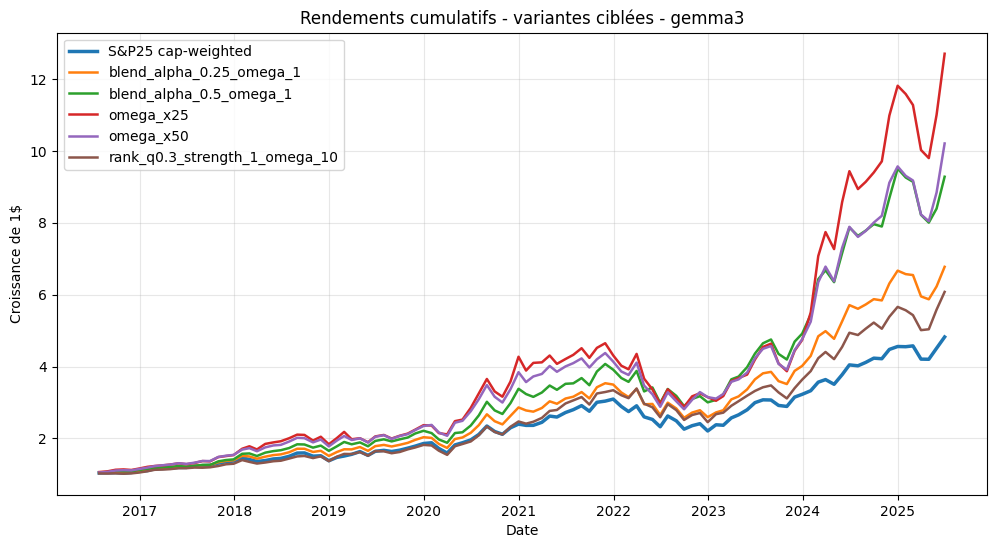

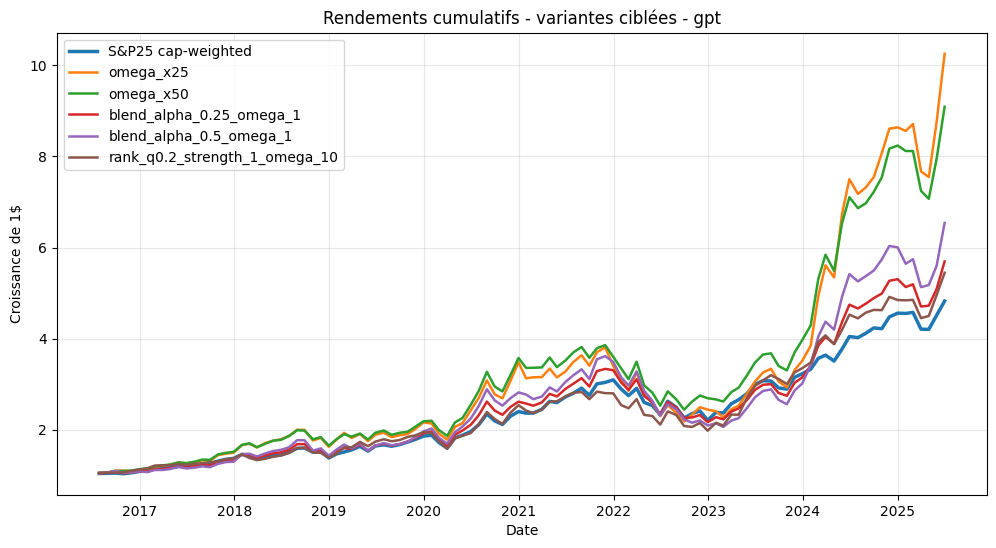

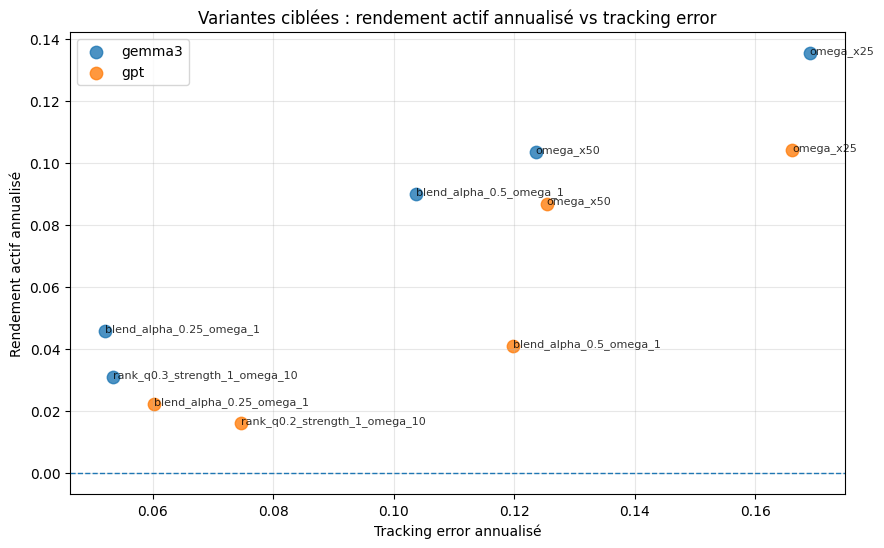

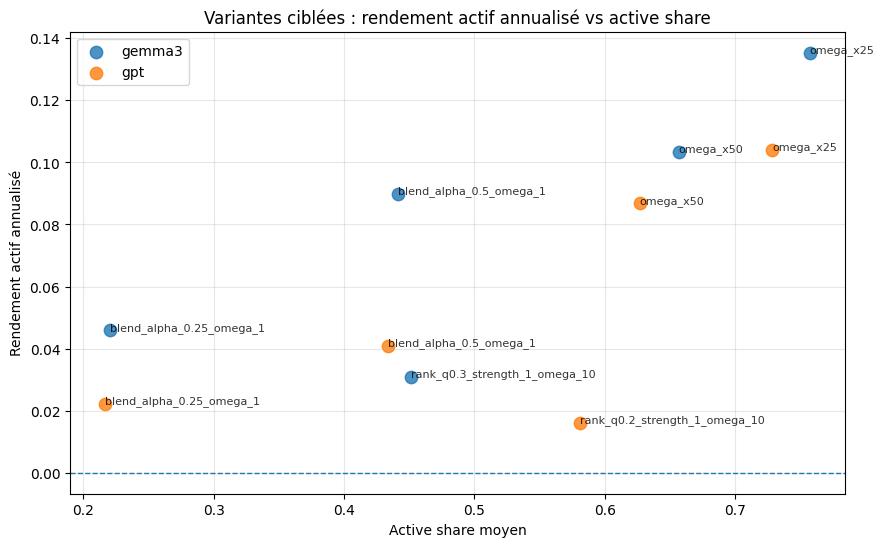

Exports créés :
diagnostics_bl_tests\target_bl_tests_summary_tau_0.025_2016-06-01_2025-06-30.csv
diagnostics_bl_tests\target_bl_tests_monthly_results_tau_0.025_2016-06-01_2025-06-30.csv
diagnostics_bl_tests\target_bl_tests_report_tau_0.025_2016-06-01_2025-06-30.xlsx


In [ ]:
# ============================
# 11. Analyse ciblée des variantes retenues
# ============================

# Variantes retenues après le premier diagnostic
TARGET_VARIANTS = {
    "gemma3": [
        "blend_alpha_0.25_omega_1",
        "blend_alpha_0.5_omega_1",
        "omega_x25",
        "omega_x50",
        "rank_q0.3_strength_1_omega_10",
    ],
    "gpt": [
        "omega_x25",
        "omega_x50",
        "blend_alpha_0.25_omega_1",
        "blend_alpha_0.5_omega_1",
        "rank_q0.2_strength_1_omega_10",
    ],
}

# ----------------------------
# 1. Filtrer les résultats ciblés
# ----------------------------
target_rows = []

for model, variants in TARGET_VARIANTS.items():
    for variant in variants:
        target_rows.append((model, variant))

target_filter = pd.Series(False, index=summary.index)

for model, variant in target_rows:
    target_filter |= (
        (summary["model"] == model)
        & (summary["variant"] == variant)
    )

target_summary = summary.loc[target_filter].copy()

# Ajouter un rang seulement sur les variantes ciblées
target_summary["target_rank_within_model"] = (
    target_summary
    .groupby("model")["ann_active_return"]
    .rank(ascending=False, method="first")
)

target_summary = target_summary.sort_values(
    ["model", "target_rank_within_model"]
).reset_index(drop=True)

cols_display = [
    "model", "test_family", "variant",
    "n_months",
    "ann_return", "sp25_ann_return", "ann_active_return",
    "ann_vol", "tracking_error", "information_ratio",
    "max_drawdown",
    "hit_months_vs_sp25",
    "mean_active_share", "mean_top5_weight", "mean_n_nonzero",
    "mean_view_corr", "mean_view_hit_rate",
    "target_rank_within_model",
]

print("Résumé des variantes ciblées")
display(target_summary[cols_display])

# ----------------------------
# 2. Vérifier s'il manque des variantes
# ----------------------------
available_pairs = set(zip(summary["model"], summary["variant"]))
missing = [
    (model, variant)
    for model, variants in TARGET_VARIANTS.items()
    for variant in variants
    if (model, variant) not in available_pairs
]

if missing:
    print("\nVariantes manquantes dans `summary` :")
    for model, variant in missing:
        print(f"- {model}: {variant}")
    print("\nCes variantes n'ont probablement pas été générées dans les boucles précédentes.")
else:
    print("\nToutes les variantes ciblées sont disponibles.")

# ----------------------------
# 3. Résultats mensuels ciblés
# ----------------------------
target_results_filter = pd.Series(False, index=results.index)

for model, variants in TARGET_VARIANTS.items():
    target_results_filter |= (
        (results["model"] == model)
        & (results["variant"].isin(variants))
    )

target_results = results.loc[target_results_filter].copy()
target_results = target_results.sort_values(["model", "variant", "date_key"]).reset_index(drop=True)

display(target_results.head())

# ----------------------------
# 4. Meilleure variante ciblée par modèle
# ----------------------------
best_target_by_model = (
    target_summary
    .sort_values(["model", "ann_active_return"], ascending=[True, False])
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

print("Meilleure variante ciblée par modèle")
display(best_target_by_model[cols_display])

# ----------------------------
# 5. Graphiques cumulatifs par modèle
# ----------------------------
for model, variants in TARGET_VARIANTS.items():
    d_model = target_results[target_results["model"] == model].copy()
    
    if d_model.empty:
        print(f"Aucun résultat ciblé pour {model}.")
        continue
    
    plt.figure(figsize=(12, 6))
    
    # Benchmark S&P25, une seule série
    bench = (
        d_model
        .drop_duplicates("date_key")
        .sort_values("date_key")
    )
    plt.plot(
        bench["date_key"],
        (1 + bench["sp25_return"]).cumprod(),
        label="S&P25 cap-weighted",
        linewidth=2.5,
    )
    
    for variant in variants:
        dv = d_model[d_model["variant"] == variant].sort_values("date_key")
        if dv.empty:
            continue
        
        plt.plot(
            dv["date_key"],
            (1 + dv["portfolio_return"]).cumprod(),
            label=variant,
            linewidth=1.8,
        )
    
    plt.title(f"Rendements cumulatifs - variantes ciblées - {model}")
    plt.xlabel("Date")
    plt.ylabel("Croissance de 1$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ----------------------------
# 6. Graphiques rendement actif annualisé vs risque actif
# ----------------------------
plt.figure(figsize=(10, 6))

for model in target_summary["model"].unique():
    d = target_summary[target_summary["model"] == model]
    plt.scatter(
        d["tracking_error"],
        d["ann_active_return"],
        label=model,
        s=80,
        alpha=0.8,
    )
    
    for _, row in d.iterrows():
        plt.annotate(
            row["variant"],
            (row["tracking_error"], row["ann_active_return"]),
            fontsize=8,
            alpha=0.8,
        )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Variantes ciblées : rendement actif annualisé vs tracking error")
plt.xlabel("Tracking error annualisé")
plt.ylabel("Rendement actif annualisé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))

for model in target_summary["model"].unique():
    d = target_summary[target_summary["model"] == model]
    plt.scatter(
        d["mean_active_share"],
        d["ann_active_return"],
        label=model,
        s=80,
        alpha=0.8,
    )
    
    for _, row in d.iterrows():
        plt.annotate(
            row["variant"],
            (row["mean_active_share"], row["ann_active_return"]),
            fontsize=8,
            alpha=0.8,
        )

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Variantes ciblées : rendement actif annualisé vs active share")
plt.xlabel("Active share moyen")
plt.ylabel("Rendement actif annualisé")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------
# 7. Export des résultats ciblés
# ----------------------------
target_summary_path = OUT_DIR / f"target_bl_tests_summary_tau_{TAU}_{START}_{END}.csv"
target_results_path = OUT_DIR / f"target_bl_tests_monthly_results_tau_{TAU}_{START}_{END}.csv"
target_excel_path = OUT_DIR / f"target_bl_tests_report_tau_{TAU}_{START}_{END}.xlsx"

target_summary.to_csv(target_summary_path, index=False)
target_results.to_csv(target_results_path, index=False)

with pd.ExcelWriter(target_excel_path, engine="openpyxl") as writer:
    target_summary.to_excel(writer, sheet_name="target_summary", index=False)
    target_results.to_excel(writer, sheet_name="target_monthly", index=False)
    best_target_by_model.to_excel(writer, sheet_name="best_by_model", index=False)

print("Exports créés :")
print(target_summary_path)
print(target_results_path)
print(target_excel_path)